# Type(품질 등급) 분류 모델 비교 — L / M / H

`ai4i2020.csv`의 `Type`(품질 등급: L/M/H)을 나머지 센서·고장 컬럼으로 예측하는 다중분류(multiclass) 문제를
4개 모델(Random Forest, XGBoost, Logistic Regression, SVM)로 학습하고, 정확도/정밀도/재현율/F1/AUC와
ROC Curve, F1 비교 막대그래프로 성능을 비교한다.

- 타겟: `Type` (L 60% / M 30% / H 10%, 다소 불균형)
- 참고: [`EDA.ipynb`](EDA.ipynb), [`README.md`](../README.md)

In [1]:
# 1. 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, classification_report, confusion_matrix,
)

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 라벨 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42

## 1. 데이터 로드 및 전처리

`Type`/`Product ID`에 앞뒤 공백이 섞여 있어(`CLAUDE.md`/`EDA2.ipynb` 참고) groupby·인코딩 전에 strip이
필요하다. 결측치/중복행은 없음(EDA에서 확인됨).

In [2]:
# 2. 데이터 로드 + 공백 정리 (EDA2.ipynb와 동일한 전처리)
df = pd.read_csv("ai4i2020.csv")
df.columns = [c.strip() for c in df.columns]
df["Type"] = df["Type"].str.strip()
df["Product ID"] = df["Product ID"].str.strip()

print("행/열 개수:", df.shape)
print("결측치 개수:", df.isna().sum().sum())
df.head()

행/열 개수: (10000, 14)
결측치 개수: 0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. 특성(X)/타겟(y) 정의

- 식별자(`UDI`, `Product ID`)와 타겟(`Type`)은 특성에서 제외한다.
- 나머지 센서값 + 고장 여부/고장 모드 플래그를 모두 특성으로 사용한다(이 컬럼들은 `Type`으로부터
  파생된 값이 아니므로 그대로 써도 데이터 누수가 아니다).
- 타겟 `Type`은 문자열(L/M/H)이라 `LabelEncoder`로 0/1/2 정수로 인코딩한다.

In [3]:
# 3. 특성/타겟 분리
feature_cols = [
    "Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
    "Torque [Nm]", "Tool wear [min]", "Machine failure",
    "TWF", "HDF", "PWF", "OSF", "RNF",
]
X = df[feature_cols].copy()
# XGBoost는 컬럼명에 [ ] < 문자가 있으면 에러를 내므로 단위 표기를 뺀 이름으로 바꿔준다
X.columns = [
    "Air_temperature", "Process_temperature", "Rotational_speed",
    "Torque", "Tool_wear", "Machine_failure",
    "TWF", "HDF", "PWF", "OSF", "RNF",
]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Type"])  # L/M/H -> 0/1/2
class_names = label_encoder.classes_
print("클래스 순서:", class_names)

클래스 순서: ['H' 'L' 'M']


## 3. 파생변수 생성

EDA에서 확인한 물리적 관계와 AI4I2020 데이터셋의 실제 고장 판정 규칙을 참고해 4개를 추가한다:

- `Temp_diff` = `Process_temperature` − `Air_temperature`: 두 온도는 상관관계가 +0.88로 매우 강해서(다중
  공선성) 원본 그대로 쓰면 사실상 같은 정보가 중복되는데, **차이값**으로 바꾸면 "공정 중 얼마나
  온도가 더 올라갔는지"라는 새로운 정보가 된다. HDF(방열 고장) 판정 기준 자체가 이 온도차 임계값(<8.6K)을
  씀.
- `Power` = `Torque` × `Rotational_speed`(rpm → rad/s로 변환): 토크 × 회전속도는 실제 기계 동력[W]이다.
  회전속도-토크가 -0.88로 강하게 역상관되어 있어(회전속도가 낮으면 토크가 높은 경향) 둘을 곱하면 이
  역상관 관계 자체가 하나의 새 신호가 된다.
- `Torque_x_ToolWear` = `Torque` × `Tool_wear`: 과부하 고장(OSF)의 실제 판정 기준이 "Torque × Tool wear가
  등급별 임계값(L=11,000 / M=12,000 / H=13,000)을 넘는지"이므로, 이 곱 자체가 `Type`과 간접적으로 얽혀
  있을 가능성이 있는 변수다.
- `Failure_mode_count` = `TWF`+`HDF`+`PWF`+`OSF`+`RNF`: 개별 고장 모드 대신 "몇 개의 고장 모드가 동시에
  발생했는지"를 하나의 숫자로 요약.

행 단위로 계산되는 결정론적 변환이라 train/test로 나누기 전에 만들어도 데이터 누수가 아니다(스케일러처럼
train 통계를 test에 새는 것과는 다름).

In [4]:
# 4. 파생변수 추가
X["Temp_diff"] = X["Process_temperature"] - X["Air_temperature"]
X["Power"] = X["Torque"] * (X["Rotational_speed"] * 2 * np.pi / 60)  # rpm -> rad/s 변환 후 동력[W] 계산
X["Torque_x_ToolWear"] = X["Torque"] * X["Tool_wear"]
X["Failure_mode_count"] = X[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum(axis=1)

print("특성 개수:", X.shape[1])
X.head()

특성 개수: 15


,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Machine_failure,TWF,HDF,PWF,OSF,RNF,Temp_diff,Power,Torque_x_ToolWear,Failure_mode_count
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.590560,0.0,0
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.722724,138.9,0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.387543,247.0,0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.504659,276.5,0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.816608,360.0,0


In [5]:
# 5. train/test 분리
# Type 비율이 60/30/10으로 불균형하므로 stratify로 train/test에도 같은 비율을 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("train:", X_train.shape, "test:", X_test.shape)

train: (8000, 15) test: (2000, 15)


## 4. 스케일링

Logistic Regression과 SVM은 거리/기울기 기반 모델이라 표준화가 필요하지만, Random Forest·XGBoost는
트리 분할 기준이라 스케일링이 필요 없다. 두 버전을 모두 준비해 모델에 맞게 사용한다.

In [6]:
# 6. 표준화 (train에만 fit, test는 transform만 — 데이터 누수 방지)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. 모델 4개 정의 및 학습

클래스 불균형(L>M>H)을 고려해 `class_weight="balanced"`를 지원하는 모델에는 적용한다.
각 모델의 입력으로 스케일링된 데이터를 쓸지, 원본 데이터를 쓸지는 모델 특성에 맞춰 딕셔너리에 함께 적어둔다.

In [7]:
# 7. 모델 정의: (모델 객체, 학습에 쓸 X_train, 테스트에 쓸 X_test)
models = {
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
        ),
        X_train, X_test,
    ),
    "XGBoost": (
        XGBClassifier(
            n_estimators=300, eval_metric="mlogloss", random_state=RANDOM_STATE
        ),
        X_train, X_test,
    ),
    "Logistic Regression": (
        LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
        ),
        X_train_scaled, X_test_scaled,
    ),
    "SVM": (
        SVC(
            kernel="rbf", probability=True,  # predict_proba로 AUC/ROC를 구하려면 probability=True 필요
            class_weight="balanced", random_state=RANDOM_STATE,
        ),
        X_train_scaled, X_test_scaled,
    ),
}

# XGBoost는 class_weight 대신 sample_weight로 불균형을 보정한다
from sklearn.utils.class_weight import compute_sample_weight
xgb_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

predictions = {}   # 모델명 -> 예측 라벨
probabilities = {} # 모델명 -> 예측 확률(클래스별)

for name, (model, X_tr, X_te) in models.items():
    if name == "XGBoost":
        model.fit(X_tr, y_train, sample_weight=xgb_sample_weight)
    else:
        model.fit(X_tr, y_train)
    predictions[name] = model.predict(X_te)
    probabilities[name] = model.predict_proba(X_te)
    print(f"{name} 학습 완료")

Random Forest 학습 완료


XGBoost 학습 완료
Logistic Regression 학습 완료


C:\Users\한국전파진흥협회\OneDrive\Desktop\sw_school\python_data_analyze\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM 학습 완료


## 6. 평가지표 — 정확도 / 정밀도 / 재현율 / F1-score / AUC

다중분류(3개 클래스)이므로 정밀도·재현율·F1은 클래스별 평균인 `macro average`를 사용하고,
AUC는 `roc_auc_score(..., multi_class="ovr", average="macro")`(One-vs-Rest macro 평균)를 사용한다.

In [8]:
# 8. 모델별 지표 계산
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])  # AUC/ROC 계산용 원-핫 형태

results = []
for name in models:
    y_pred = predictions[name]
    y_proba = probabilities[name]

    results.append({
        "모델": name,
        "정확도": accuracy_score(y_test, y_pred),
        "정밀도(macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "재현율(macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1-score(macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "AUC(macro, OvR)": roc_auc_score(y_test_binarized, y_proba, multi_class="ovr", average="macro"),
    })

results_df = pd.DataFrame(results).set_index("모델").sort_values("F1-score(macro)", ascending=False)
results_df.round(4)

,정확도,정밀도(macro),재현율(macro),F1-score(macro),"AUC(macro, OvR)"
모델,,,,,
XGBoost,0.4935,0.3272,0.3323,0.3276,0.5032
Random Forest,0.4920,0.3260,0.3301,0.3245,0.5091
Logistic Regression,0.2390,0.3291,0.3303,0.2331,0.4970
SVM,0.2225,0.3036,0.2965,0.2176,0.4783


In [9]:
# 9. 모델별 상세 리포트(클래스별 precision/recall/f1)와 혼동행렬
for name in models:
    print(f"===== {name} =====")
    print(classification_report(y_test, predictions[name], target_names=class_names, zero_division=0))
    print("혼동행렬 (행=실제, 열=예측):")
    print(pd.DataFrame(
        confusion_matrix(y_test, predictions[name]),
        index=class_names, columns=class_names,
    ))
    print()

===== Random Forest =====
              precision    recall  f1-score   support

           H       0.08      0.03      0.05       201
           L       0.60      0.67      0.63      1200
           M       0.30      0.28      0.29       599

    accuracy                           0.49      2000
   macro avg       0.33      0.33      0.32      2000
weighted avg       0.46      0.49      0.47      2000

혼동행렬 (행=실제, 열=예측):
    H    L    M
H   7  140   54
L  57  808  335
M  27  403  169

===== XGBoost =====
              precision    recall  f1-score   support

           H       0.06      0.03      0.04       201
           L       0.60      0.67      0.63      1200
           M       0.32      0.29      0.30       599

    accuracy                           0.49      2000
   macro avg       0.33      0.33      0.33      2000
weighted avg       0.46      0.49      0.48      2000

혼동행렬 (행=실제, 열=예측):
    H    L    M
H   7  143   51
L  73  806  321
M  33  392  174

===== Logistic Regressio

## 6-1. 특성 중요도 (Random Forest 기준)

새로 만든 파생변수가 실제로 쓸모 있는지 확인하기 위해, 트리 기반 모델이라 `feature_importances_`를 바로
읽을 수 있는 Random Forest의 특성 중요도를 본다.

In [10]:
# 9-1. Random Forest 특성 중요도
rf_model = models["Random Forest"][0]
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.round(4)

Power                  0.1419
Torque_x_ToolWear      0.1393
Rotational_speed       0.1379
Torque                 0.1324
Tool_wear              0.1274
Air_temperature        0.1070
Process_temperature    0.1059
Temp_diff              0.0997
Failure_mode_count     0.0023
OSF                    0.0019
Machine_failure        0.0017
TWF                    0.0009
PWF                    0.0007
RNF                    0.0006
HDF                    0.0005
dtype: float64

## 7. 모델별 ROC Curve

다중분류라 클래스마다(One-vs-Rest) ROC Curve가 하나씩 나온다. 모델 4개를 2x2로 배치하고, 각 서브플롯 안에
L/M/H 클래스별 ROC Curve + macro-average ROC Curve를 함께 그린다.

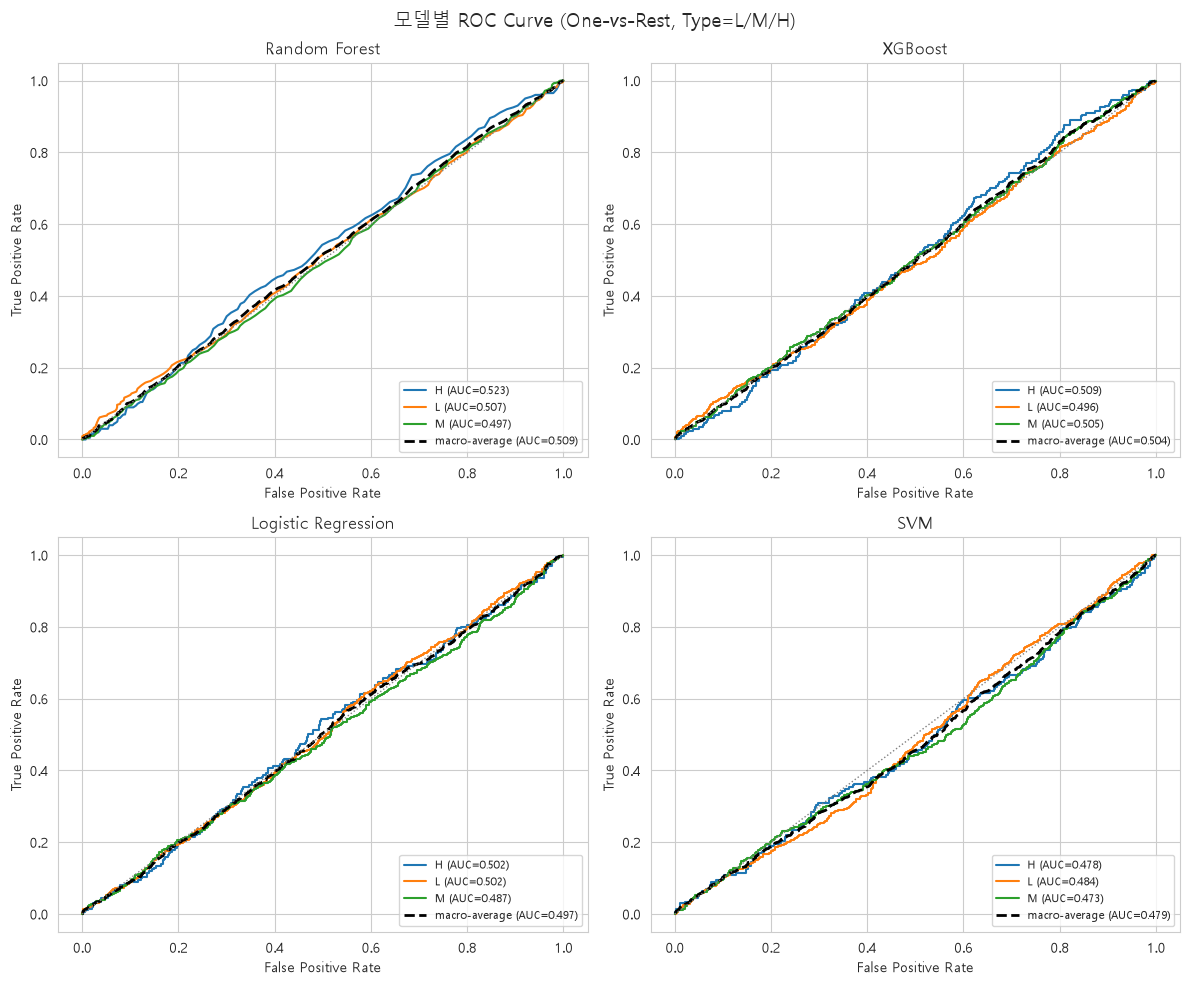

In [11]:
# 10. 모델별 ROC Curve (2x2 서브플롯)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, name in zip(axes.ravel(), models):
    y_proba = probabilities[name]

    fpr, tpr, roc_auc = {}, {}, {}
    for i, cls in enumerate(class_names):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax.plot(fpr[i], tpr[i], label=f"{cls} (AUC={roc_auc[i]:.3f})")

    # macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(class_names)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(class_names)
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, "k--", linewidth=2, label=f"macro-average (AUC={macro_auc:.3f})")

    ax.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1)  # 랜덤 분류 기준선
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=8)

fig.suptitle("모델별 ROC Curve (One-vs-Rest, Type=L/M/H)", fontsize=14)
fig.tight_layout()
fig.savefig("../images/model_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 모델별 F1-score 비교

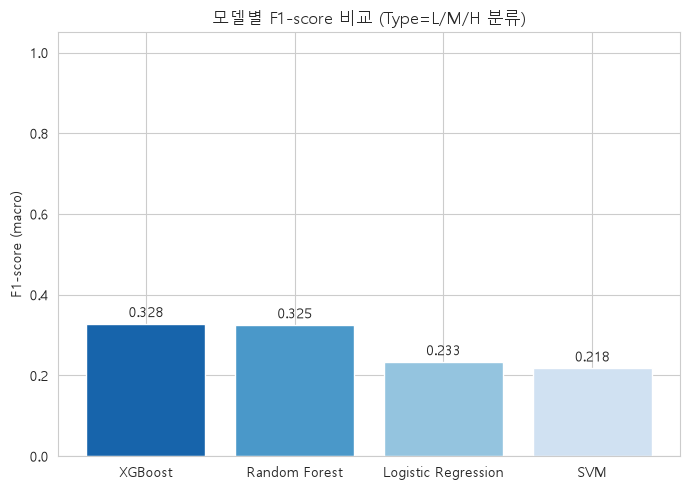

In [12]:
# 11. 모델별 F1-score(macro) 비교 막대그래프
fig, ax = plt.subplots(figsize=(7, 5))
f1_sorted = results_df["F1-score(macro)"].sort_values(ascending=False)
bars = ax.bar(f1_sorted.index, f1_sorted.values, color=sns.color_palette("Blues_r", len(f1_sorted)))

for bar, value in zip(bars, f1_sorted.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.3f}",
            ha="center", va="bottom", fontsize=10)

ax.set_ylim(0, 1.05)
ax.set_ylabel("F1-score (macro)")
ax.set_title("모델별 F1-score 비교 (Type=L/M/H 분류)")
fig.tight_layout()
fig.savefig("../images/model_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. 결론

파생변수 4개(`Temp_diff`, `Power`, `Torque_x_ToolWear`, `Failure_mode_count`)를 추가한 뒤 F1-score(macro)
기준 **XGBoost(0.328) > Random Forest(0.325) > Logistic Regression(0.233) > SVM(0.218)** 순이었고,
AUC(macro, OvR)는 **Random Forest(0.509) > XGBoost(0.503) > Logistic Regression(0.497) > SVM(0.478)**로
여전히 0.5 안팎이었다(파생변수 추가 전과 거의 같은 수준: RF/XGB F1 0.325→0.325/0.322→0.328, AUC
0.512→0.509/0.487→0.503 — 미세하게 오르내렸을 뿐 유의미한 개선은 아니다).

- **파생변수를 추가해도 전체 성능(AUC, F1)은 거의 그대로다** — 여전히 랜덤 수준. 즉 물리적으로 그럴듯한
  변수를 더 만들어 넣는다고 `Type` 예측력이 좋아지지 않았고, 이는 "특성을 더 정교하게 다듬으면 될
  문제"가 아니라 데이터 자체에 `Type`을 알려줄 신호가 거의 없다는 8번 절 결론을 다시 한번 뒷받침한다.
- 다만 **Random Forest 특성 중요도**를 보면 흥미로운 지점이 있다 — 새로 만든 `Power`(0.142)와
  `Torque_x_ToolWear`(0.139)가 원본 변수 `Rotational_speed`(0.138)/`Torque`(0.132)/`Tool_wear`(0.127)보다
  오히려 중요도가 더 높게 나왔다. 즉 모델이 원본 변수 각각보다 두 변수를 곱한 파생변수 쪽에서 조금 더
  많은 정보를 뽑아내긴 했다는 뜻이다 — 다만 그 "조금 더 뽑아낸 정보"가 전체 AUC/F1을 유의미하게
  끌어올릴 정도는 아니었다(신호 자체가 원래 매우 약하기 때문).
- 개별 고장 모드 플래그(`TWF`/`HDF`/`PWF`/`OSF`/`RNF`)와 이를 합친 `Failure_mode_count`, `Machine_failure`는
  중요도가 전부 0.003 이하로 사실상 무시된다 — Type 예측에는 "고장이 났는지"보다 "온도/속도/토크가
  어떤 값이었는지"가 (미미하게나마) 더 관련 있다는 의미.
- 두 그래프(`../images/model_roc_curves.png`, `../images/model_f1_comparison.png`)도 여전히 ROC Curve가
  대각선(랜덤 기준선)에 가깝게 나타나 같은 결론을 재확인해준다.
- 실행: 저장소 루트에서 `jupyter nbconvert --to notebook --execute --inplace src/classifications.ipynb`
  (다른 노트북과 마찬가지로 nbconvert 작업 디렉터리가 `src/`가 되므로 `ai4i2020.csv`를 상대경로로 바로
  읽고, 그래프는 `../images/`에 저장된다).